In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# 1. 读取数据
file_path = r"D:\vscode\corpus data\sklearn\UNSC_2.xlsx"
df = pd.read_excel(file_path)

In [3]:
# 2. 文本预处理
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)    # remove punctuations
    text = re.sub(r'\s+', ' ', text)       # normalize whitespace
    return text.strip()

In [4]:
df['processed_text'] = df.iloc[:, 1].astype(str).apply(preprocess_text)
y = df.iloc[:, 0].astype(str).values
texts = df['processed_text']

In [5]:
# 3. n-grams feature extraction (1-3gram）
vectorizer = CountVectorizer(ngram_range=(1,3), analyzer='word', lowercase=False)
X = vectorizer.fit_transform(texts)

In [18]:
feature_names = vectorizer.get_feature_names_out()

X_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

print(X_df.head())

   access  access all  access all parties  access all relevant  access china  \
0       0           0                   0                    0             0   
1       1           0                   0                    0             0   
2       2           0                   0                    0             1   
3       1           0                   0                    0             1   
4       1           0                   0                    0             0   

   access china always  access development  access development is  \
0                    0                   0                      0   
1                    0                   0                      0   
2                    1                   0                      0   
3                    1                   0                      0   
4                    0                   0                      0   

   access grave  access grave violations  ...  we welcome operational  \
0             0                

In [7]:
# 4. normalize the n-grams and dimension reduced to 50
X_norm = normalize(X)
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_norm.toarray())

In [17]:
print("X shape:", X.shape)
print("Number of n-gram features:", X.shape[1])

X shape: (900, 2720)
Number of n-gram features: 2720


In [10]:
# 5. train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_50, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
# 6. 5-fold cross-validation
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
print("5-Fold Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy: {:.4f} (+/- {:.4f})".format(np.mean(cv_scores), np.std(cv_scores)))

5-Fold Cross-Validation Accuracy Scores: [0.97222222 0.95138889 0.98611111 0.97916667 0.95833333]
Mean CV Accuracy: 0.9694 (+/- 0.0129)


In [12]:
# 7. modeling: for prediction
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [13]:
# 8. provide classificatin reports
print("\nClassification report on test set:")
print(classification_report(y_test, y_pred))


Classification report on test set:
              precision    recall  f1-score   support

         C-E       1.00      0.91      0.95        90
  Original E       0.92      1.00      0.96        90

    accuracy                           0.96       180
   macro avg       0.96      0.96      0.96       180
weighted avg       0.96      0.96      0.96       180



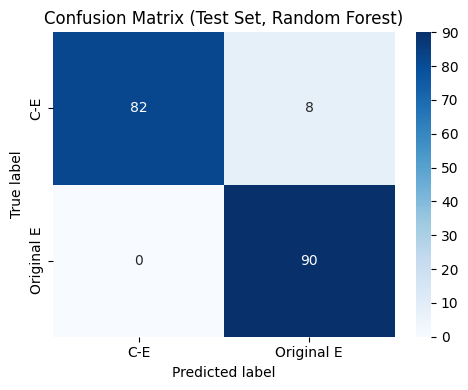

In [14]:
# 9. provide confusion matrix 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Test Set, Random Forest)')
plt.tight_layout()
plt.show()

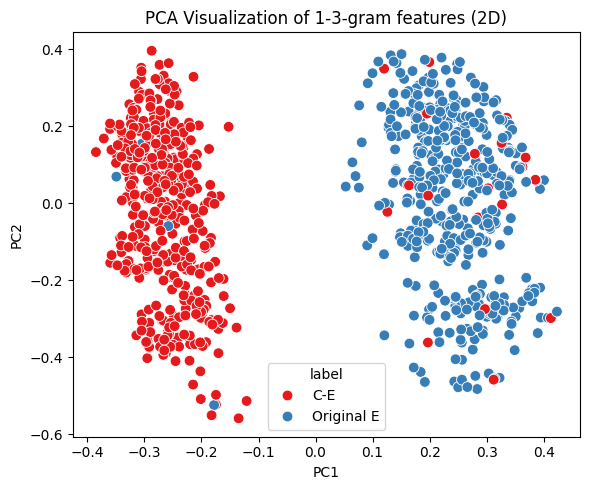

In [15]:
# 10. 2-dimensional visualization (before or after modeling for different purposes)
pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_norm.toarray())
df_viz = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
df_viz['label'] = y
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_viz, x='PC1', y='PC2', hue='label', palette='Set1', s=60)
plt.title('PCA Visualization of 1-3-gram features (2D)')
plt.tight_layout()
plt.show()